In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [3]:
df = pd.read_csv('../data/customer_journey.csv')
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Shape: (12719, 10)
Columns: ['SessionID', 'UserID', 'Timestamp', 'PageType', 'DeviceType', 'Country', 'ReferralSource', 'TimeOnPage_seconds', 'ItemsInCart', 'Purchased']


In [4]:
df.head(10)

,SessionID,UserID,Timestamp,PageType,DeviceType,Country,ReferralSource,TimeOnPage_seconds,ItemsInCart,Purchased
0,session_0,user_2223,2025-01-20 22:53:34,home,Desktop,India,Social Media,55,0,0
1,session_1,user_2192,2025-02-26 12:57:10,home,Tablet,Germany,Email,99,0,0
2,session_1,user_2192,2025-02-26 12:59:11,product_page,Tablet,Germany,Email,121,0,0
3,session_2,user_1708,2025-06-24 15:40:46,home,Mobile,India,Google,160,0,0
4,session_3,user_2976,2025-06-11 07:21:02,home,Tablet,UK,Google,113,0,0
5,session_4,user_1065,2025-04-12 23:58:16,home,Desktop,France,Social Media,49,0,0
6,session_4,user_1065,2025-04-13 00:00:31,product_page,Desktop,France,Social Media,135,4,0
7,session_5,user_2216,2025-01-08 20:58:18,home,Desktop,UK,Email,155,0,1
8,session_5,user_2216,2025-01-08 20:59:57,product_page,Desktop,UK,Email,99,0,1
9,session_5,user_2216,2025-01-08 21:00:23,cart,Desktop,UK,Email,26,5,1


In [5]:
print("Data Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())

Data Types:
SessionID             object
UserID                object
Timestamp             object
PageType              object
DeviceType            object
Country               object
ReferralSource        object
TimeOnPage_seconds     int64
ItemsInCart            int64
Purchased              int64
dtype: object

Missing Values:
SessionID             0
UserID                0
Timestamp             0
PageType              0
DeviceType            0
Country               0
ReferralSource        0
TimeOnPage_seconds    0
ItemsInCart           0
Purchased             0
dtype: int64


In [7]:
print("Unique PageTypes (your funnel stages):")
print(df['PageType'].value_counts())

Unique PageTypes (your funnel stages):
PageType
home            5000
product_page    3987
cart            1599
checkout        1123
confirmation    1010
Name: count, dtype: int64


In [8]:
print("Devices:", df['DeviceType'].unique())
print("Countries:", df['Country'].unique())
print("Referral Sources:", df['ReferralSource'].unique())
print("Purchased (0=No, 1=Yes):\n", df['Purchased'].value_counts())

Devices: ['Desktop' 'Tablet' 'Mobile']
Countries: ['India' 'Germany' 'UK' 'France' 'Australia' 'USA' 'Canada']
Referral Sources: ['Social Media' 'Email' 'Google' 'Direct']
Purchased (0=No, 1=Yes):
 Purchased
0    7669
1    5050
Name: count, dtype: int64


In [9]:
# Funnel stage order
funnel_stages = ['home', 'product_page', 'cart', 'checkout', 'confirmation']

# Count unique users at each stage
funnel_counts = df[df['PageType'].isin(funnel_stages)] \
    .groupby('PageType')['UserID'].nunique()

# Reorder properly
funnel_counts = funnel_counts.reindex(funnel_stages)

print("Users at each funnel stage:")
print(funnel_counts)

Users at each funnel stage:
PageType
home            1872
product_page    1763
cart            1084
checkout         855
confirmation     792
Name: UserID, dtype: int64


In [10]:
# Conversion rate at each stage
funnel_df = pd.DataFrame({
    'Stage': funnel_stages,
    'Users': funnel_counts.values
})

# % compared to previous stage (step-by-step drop-off)
funnel_df['Drop_off_%'] = funnel_df['Users'].pct_change() * 100
funnel_df['Drop_off_%'] = funnel_df['Drop_off_%'].round(2)

# % compared to first stage (overall conversion)
funnel_df['Conversion_from_start_%'] = (funnel_df['Users'] / funnel_df['Users'].iloc[0] * 100).round(2)

print(funnel_df.to_string(index=False))

       Stage  Users  Drop_off_%  Conversion_from_start_%
        home   1872         NaN                   100.00
product_page   1763       -5.82                    94.18
        cart   1084      -38.51                    57.91
    checkout    855      -21.13                    45.67
confirmation    792       -7.37                    42.31


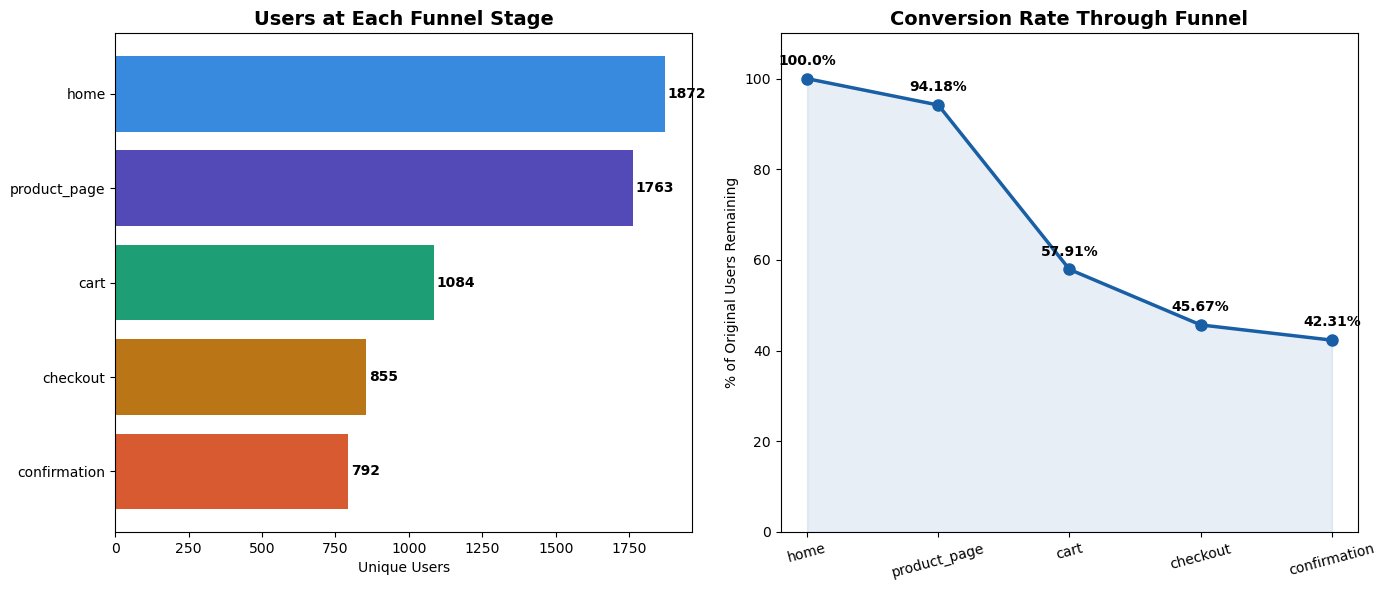

Chart saved!


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Chart 1: Funnel Bar Chart ---
colors = ['#378ADD', '#534AB7', '#1D9E75', '#BA7517', '#D85A30']
bars = axes[0].barh(funnel_df['Stage'][::-1], funnel_df['Users'][::-1], color=colors[::-1])
axes[0].set_title('Users at Each Funnel Stage', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Unique Users')
for bar, val in zip(bars, funnel_df['Users'][::-1]):
    axes[0].text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
                 str(val), va='center', fontweight='bold')

# --- Chart 2: Conversion from Start ---
axes[1].plot(funnel_df['Stage'], funnel_df['Conversion_from_start_%'],
             marker='o', color='#185FA5', linewidth=2.5, markersize=8)
axes[1].fill_between(range(len(funnel_df)), funnel_df['Conversion_from_start_%'],
                     alpha=0.1, color='#185FA5')
axes[1].set_title('Conversion Rate Through Funnel', fontsize=14, fontweight='bold')
axes[1].set_ylabel('% of Original Users Remaining')
axes[1].set_xticks(range(len(funnel_df)))
axes[1].set_xticklabels(funnel_df['Stage'], rotation=15)
axes[1].set_ylim(0, 110)
for i, val in enumerate(funnel_df['Conversion_from_start_%']):
    axes[1].annotate(f'{val}%', (i, val), textcoords="offset points",
                     xytext=(0, 10), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../data/funnel_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [12]:
# Conversion rate by Device Type
device_conversion = df[df['PageType'] == 'confirmation'] \
    .groupby('DeviceType')['UserID'].nunique()

device_total = df[df['PageType'] == 'home'] \
    .groupby('DeviceType')['UserID'].nunique()

device_df = pd.DataFrame({
    'Purchased': device_conversion,
    'Total': device_total
})
device_df['Conversion_%'] = (device_df['Purchased'] / device_df['Total'] * 100).round(2)
print("Conversion Rate by Device:")
print(device_df)
print()

# Conversion rate by Referral Source
ref_conversion = df[df['PageType'] == 'confirmation'] \
    .groupby('ReferralSource')['UserID'].nunique()

ref_total = df[df['PageType'] == 'home'] \
    .groupby('ReferralSource')['UserID'].nunique()

ref_df = pd.DataFrame({
    'Purchased': ref_conversion,
    'Total': ref_total
})
ref_df['Conversion_%'] = (ref_df['Purchased'] / ref_df['Total'] * 100).round(2)
print("Conversion Rate by Referral Source:")
print(ref_df)

Conversion Rate by Device:
            Purchased  Total  Conversion_%
DeviceType                                
Desktop           315   1161         27.13
Mobile            312   1127         27.68
Tablet            313   1137         27.53

Conversion Rate by Referral Source:
                Purchased  Total  Conversion_%
ReferralSource                                
Direct                230    925         24.86
Email                 230    940         24.47
Google                262    969         27.04
Social Media          225    915         24.59


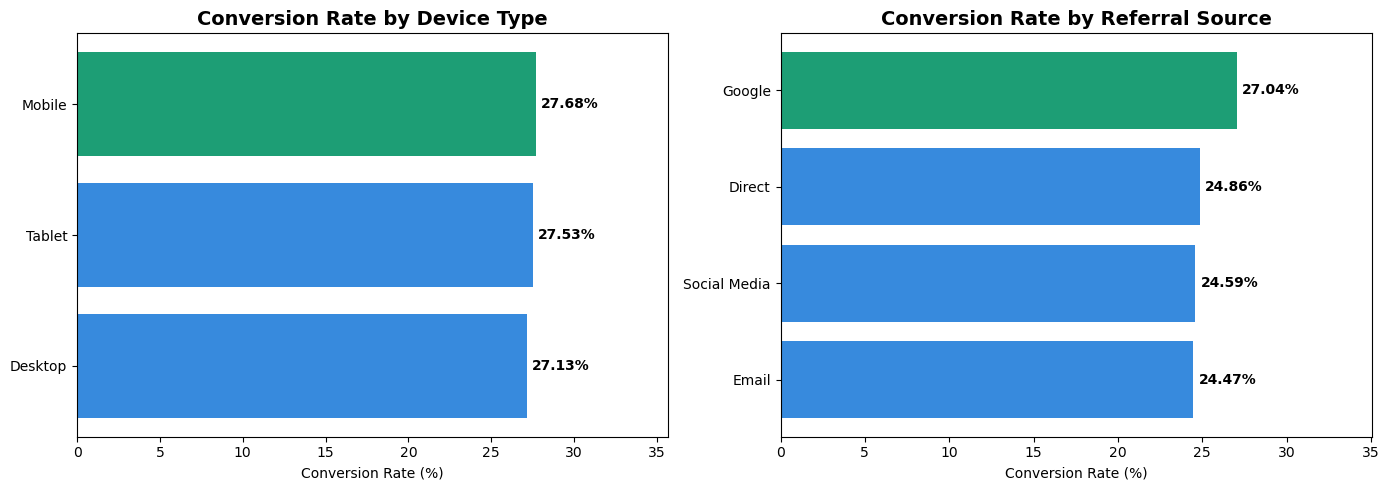

Segmentation chart saved!


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Chart 1: Conversion by Device ---
device_df_sorted = device_df.sort_values('Conversion_%', ascending=True)
colors_device = ['#378ADD' if x != device_df['Conversion_%'].max() 
                 else '#1D9E75' for x in device_df_sorted['Conversion_%']]
bars1 = axes[0].barh(device_df_sorted.index, device_df_sorted['Conversion_%'], color=colors_device)
axes[0].set_title('Conversion Rate by Device Type', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Conversion Rate (%)')
for bar, val in zip(bars1, device_df_sorted['Conversion_%']):
    axes[0].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{val}%', va='center', fontweight='bold')
axes[0].set_xlim(0, device_df_sorted['Conversion_%'].max() + 8)

# --- Chart 2: Conversion by Referral Source ---
ref_df_sorted = ref_df.sort_values('Conversion_%', ascending=True)
colors_ref = ['#378ADD' if x != ref_df['Conversion_%'].max() 
              else '#1D9E75' for x in ref_df_sorted['Conversion_%']]
bars2 = axes[1].barh(ref_df_sorted.index, ref_df_sorted['Conversion_%'], color=colors_ref)
axes[1].set_title('Conversion Rate by Referral Source', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Conversion Rate (%)')
for bar, val in zip(bars2, ref_df_sorted['Conversion_%']):
    axes[1].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{val}%', va='center', fontweight='bold')
axes[1].set_xlim(0, ref_df_sorted['Conversion_%'].max() + 8)

plt.tight_layout()
plt.savefig('../data/segmentation_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("Segmentation chart saved!")

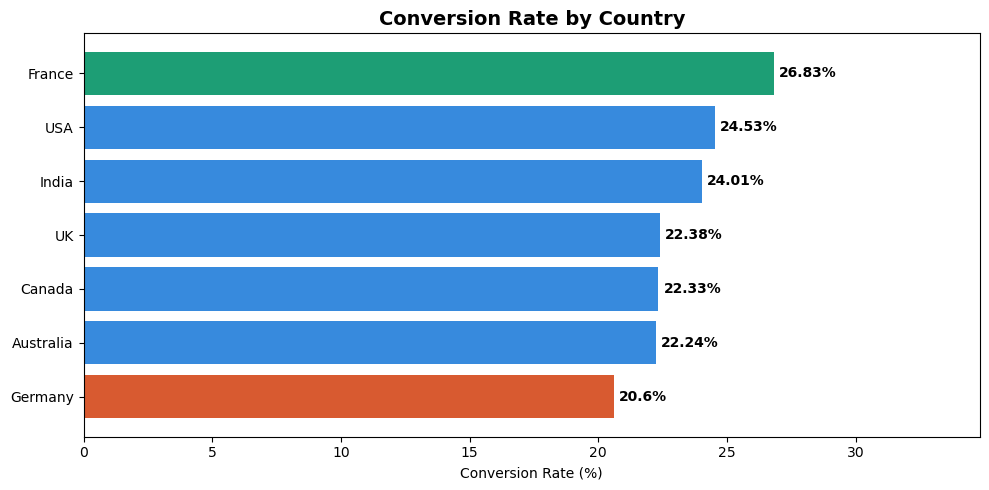

           Purchased  Total  Conversion_%
Country                                  
Germany          124    602         20.60
Australia        127    571         22.24
Canada           134    600         22.33
UK               141    630         22.38
India            139    579         24.01
USA              143    583         24.53
France           165    615         26.83


In [14]:
# Conversion rate by Country
country_conversion = df[df['PageType'] == 'confirmation'] \
    .groupby('Country')['UserID'].nunique()

country_total = df[df['PageType'] == 'home'] \
    .groupby('Country')['UserID'].nunique()

country_df = pd.DataFrame({
    'Purchased': country_conversion,
    'Total': country_total
})
country_df['Conversion_%'] = (country_df['Purchased'] / country_df['Total'] * 100).round(2)
country_df_sorted = country_df.sort_values('Conversion_%', ascending=True)

plt.figure(figsize=(10, 5))
colors_country = ['#1D9E75' if x == country_df['Conversion_%'].max() 
                  else '#D85A30' if x == country_df['Conversion_%'].min() 
                  else '#378ADD' for x in country_df_sorted['Conversion_%']]
bars = plt.barh(country_df_sorted.index, country_df_sorted['Conversion_%'], color=colors_country)
plt.title('Conversion Rate by Country', fontsize=14, fontweight='bold')
plt.xlabel('Conversion Rate (%)')
for bar, val in zip(bars, country_df_sorted['Conversion_%']):
    plt.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
             f'{val}%', va='center', fontweight='bold')
plt.xlim(0, country_df_sorted['Conversion_%'].max() + 8)
plt.tight_layout()
plt.savefig('../data/country_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print(country_df_sorted[['Purchased', 'Total', 'Conversion_%']])